In [19]:
"""
    File: modello.ipynb
    Author: Andrea Macale
    Date: 2026-03-04

    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici

"""

'\n    File: modello.ipynb\n    Author: Andrea Macale\n    Date: 2026-03-04\n\n    Description: Notebook per la realizzazione del modello per il suggerimento ed analisi di follow-up clinici\n\n'

# Parte 0: Importazione delle librerie

In [20]:
%pip install -r requirements.txt -q

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


## Librerie principali

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

In [22]:
import sys

# Si sposta nella directory principale dello Studio
os.chdir('/teamspace/studios/this_studio')
#path = os.path.expanduser('~/Documenti/Tesi-Magistrale')
#os.chdir(path)
# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /teamspace/studios/this_studio


## Correlazione 

In [23]:
from sklearn.preprocessing import LabelEncoder
import scipy.stats
from scipy.stats import spearmanr

## VIF

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

## Distribuzione dei dati

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Train

In [103]:
import torch
import torchvision.transforms as T
import torch.nn as nn
from src.train.train import train_modello_visivo, train_modello_clinico
from src.models.DiagnosiIntegrata import DiagnosiIntegrata
from src.models.DiagnosiVisiva import DiagnosiVisiva
from src.train.evaluator import Evaluator
from src.features.RXToraceDataset import RXToraceDataset
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer, util
from torch.utils.data import DataLoader

In [27]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# Parte 1: Estrazione dei dati

## Aperta dei file del dataset

In [28]:
pos_dataset = os.path.join("data")

In [29]:
file = os.path.join(pos_dataset, "patients.csv")
pazienti = pd.read_csv(file)
pazienti['subject_id'] = pazienti['subject_id'].astype(str)
pazienti.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [30]:
file = os.path.join(pos_dataset, "diagnoses_icd.csv")
tipi = {
    'subject_id': str, 
    'hadm_id': str, 
    'icd_code': str, 
    'icd_version': str
}
diagnosi = pd.read_csv(file, dtype=tipi)
diagnosi['icd_version'] = pd.to_numeric(diagnosi['icd_version'], errors='coerce').fillna(0).astype(int)
diagnosi = diagnosi.drop_duplicates()
diagnosi.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [31]:
file = os.path.join(pos_dataset, "mimic-cxr-2.0.0-metadata.csv")
metadati = pd.read_csv(file)
metadati['dicom_id'] = metadati['dicom_id'].astype(str)
metadati['subject_id'] = metadati['subject_id'].astype(str)
metadati['study_id'] = metadati['study_id'].astype(str)
metadati.head()

,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,50414267,CHEST (PA AND LAT),PA,3056,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,50414267,CHEST (PA AND LAT),LATERAL,3056,2544,21800506,213014.531,CHEST (PA AND LAT),lateral,Erect
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,53189527,CHEST (PA AND LAT),PA,3056,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect
3,e084de3b-be89b11e-20fe3f9f-9c8d8dfe-4cfd202c,10000032,53189527,CHEST (PA AND LAT),LATERAL,3056,2544,21800626,165500.312,CHEST (PA AND LAT),lateral,Erect
4,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,10000032,53911762,CHEST (PORTABLE AP),AP,2705,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN


In [32]:
file = os.path.join(pos_dataset, "icustays.csv")
visite = pd.read_csv(file)
visite['subject_id'] = metadati['subject_id'].astype(str)
visite.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000032,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000032,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10000032,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10000032,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [33]:
file = os.path.join(pos_dataset, "admissions.csv")
ammissioni = pd.read_csv(file)
ammissioni['subject_id'] = ammissioni['subject_id'].astype(str)
ammissioni

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546023,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaN,EW EMER.,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2149-01-08 09:11:00,2149-01-08 18:12:00,0
546024,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaN,EW EMER.,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,2147-07-17 17:18:00,2147-07-18 17:34:00,0
546025,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1
546026,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaN,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0


In [34]:
lista_immagini = []
ricerca = Path(os.path.join(pos_dataset, "MIMIC_SUPER_RES_24K"))
for file_path in ricerca.rglob('*.jpg'):
    dicom_id = file_path.stem
    lista_immagini.append({'dicom_id': dicom_id, 'path_immagine': str(file_path)})
immagini = pd.DataFrame(lista_immagini)
immagini['path_immagine'] = immagini['path_immagine'].str.replace(str(pos_dataset+"/"), "data/", regex=False) # pulisci il path
immagini['dicom_id'] = immagini['dicom_id'].astype(str)
print(f"{len(immagini)} immagini")
immagini.head()

24000 immagini


,dicom_id,path_immagine
0,0006a816-5140e307-815c7b9f-4856cbc6-670b7e6d,data/MIMIC_SUPER_RES_24K/0006a816-5140e307-815...
1,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...
2,000fe830-f18703f9-765fd2d6-eb316278-1bd6e8d2,data/MIMIC_SUPER_RES_24K/000fe830-f18703f9-765...
3,00126448-9dfa1383-58c9cb80-9b78c170-5ca8bf1c,data/MIMIC_SUPER_RES_24K/00126448-9dfa1383-58c...
4,0013b91b-c4487243-1bacad43-6a4c135c-d4379557,data/MIMIC_SUPER_RES_24K/0013b91b-c4487243-1ba...


In [35]:
df_referti = pd.merge(immagini, metadati, on='dicom_id', how='inner')
df_referti

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning
0,0006a816-5140e307-815c7b9f-4856cbc6-670b7e6d,data/MIMIC_SUPER_RES_24K/0006a816-5140e307-815...,14533062,55979577,NaN,PA,2022,2022,21180531,100918.000,CHEST (PA AND LAT),postero-anterior,Erect
1,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,10001401,50225296,PORTABLE ABDOMEN,AP,3056,2544,21310610,102234.484,DX CHEST PORT LINE/TUBE PLCMT 1 EXAM,antero-posterior,Erect
2,000fe830-f18703f9-765fd2d6-eb316278-1bd6e8d2,data/MIMIC_SUPER_RES_24K/000fe830-f18703f9-765...,16141152,58262736,CHEST (PORTABLE AP),AP,3056,2544,21970914,175220.593,CHEST (PORTABLE AP),antero-posterior,Erect
3,00126448-9dfa1383-58c9cb80-9b78c170-5ca8bf1c,data/MIMIC_SUPER_RES_24K/00126448-9dfa1383-58c...,18455225,55296482,CHEST (PORTABLE AP),AP,3050,2539,21710523,95156.625,CHEST (PORTABLE AP),antero-posterior,Erect
4,0013b91b-c4487243-1bacad43-6a4c135c-d4379557,data/MIMIC_SUPER_RES_24K/0013b91b-c4487243-1ba...,18362456,50302550,CHEST (PA AND LAT),PA,2544,3056,21380401,122157.046,CHEST (PA AND LAT),postero-anterior,Erect
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,ffec9318-396f471a-94330422-ccce2d6b-01e130b9,data/MIMIC_SUPER_RES_24K/ffec9318-396f471a-943...,11017660,50720121,NaN,PA,2022,1736,21720220,94610.000,CHEST (PA AND LAT),postero-anterior,Erect
23996,ffecd6b4-9c8fc902-598013ee-90d09c4e-a3341b4d,data/MIMIC_SUPER_RES_24K/ffecd6b4-9c8fc902-598...,14849354,56669562,Performed Desc,PA,1966,1870,21781202,164957.000,CHEST (PA AND LAT),postero-anterior,Recumbent
23997,ffede0ba-5b5d8b13-a4c6b4d5-097504d5-e427c37f,data/MIMIC_SUPER_RES_24K/ffede0ba-5b5d8b13-a4c...,19611909,55026704,CHEST (PORTABLE AP),AP,3050,2539,21601121,102307.640,CHEST (PORTABLE AP),antero-posterior,Erect
23998,ffee7878-19b88739-52eacb48-78461a37-eae68bf2,data/MIMIC_SUPER_RES_24K/ffee7878-19b88739-52e...,10607556,57206622,CHEST (PA AND LAT),PA,2544,3056,21850701,92103.953,CHEST (PA AND LAT),postero-anterior,Erect


In [36]:
id_necessari = set(df_referti['study_id']) 
ricerca_referti = Path(os.path.join(pos_dataset, "mimic-cxr-reports"))
tutti_i_files_txt = list(ricerca_referti.rglob('*.txt'))
files_filtrati = [f for f in tutti_i_files_txt if f.stem.replace("s", "") in id_necessari]
print(f"Referti totali: {len(tutti_i_files_txt)} | Referti da leggere: {len(files_filtrati)}")

Referti totali: 227835 | Referti da leggere: 23730


In [37]:
def leggi_singolo_referto(file_path):
    """Funzione helper per la lettura parallela"""
    study_id = file_path.stem.replace("s", "")
    with open(file_path, 'r', encoding='utf-8') as f:
        testo = f.read()
    return {'study_id': str(study_id), 'testo_referto': testo}

lista_referti = []
ricerca_referti = Path(os.path.join(pos_dataset, "mimic-cxr-reports"))
files = list(ricerca_referti.rglob('*.txt'))

print(f"Inizio caricamento di {len(files)} file...")

with ThreadPoolExecutor(max_workers=8) as executor:
    lista_referti = list(tqdm(executor.map(leggi_singolo_referto, files_filtrati), total=len(files_filtrati)))

referti = pd.DataFrame(lista_referti)

Inizio caricamento di 227835 file...


  0%|          | 0/23730 [00:00<?, ?it/s]

## Prima pulizia, selezione e join dei dati

In [38]:
dataset = immagini.copy()
dataset = dataset.merge(metadati, on=['dicom_id'], how='inner')
dataset = dataset.merge(referti, on=['study_id'], how='inner')
dataset = dataset.merge(pazienti, on=['subject_id'], how='inner')
ammissioni_uniche = ammissioni.drop_duplicates(subset=['subject_id'], keep='last')
dataset = dataset.merge(ammissioni_uniche, on=['subject_id'], how='inner')
visite_uniche = visite.drop_duplicates(subset=['subject_id'], keep='last')
dataset = dataset.merge(visite_uniche, on=['subject_id'], how='inner')
print(f"Dimensioni finali sicure: {len(dataset)} righe")
dataset.head()

Dimensioni finali sicure: 5324 righe


,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,edregtime,edouttime,hospital_expire_flag,hadm_id_y,stay_id,first_careunit,last_careunit,intime,outtime,los
0,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,10001401,50225296,PORTABLE ABDOMEN,AP,3056,2544,21310610,102234.484,...,2136-12-30 00:20:00,2136-12-30 04:06:00,0,22987108,32359580,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2146-06-22 11:46:29,2146-07-13 00:27:47,20.528681
1,00155f06-795059b5-c0dcb4ef-f20f9bc0-537aa1d4,data/MIMIC_SUPER_RES_24K/00155f06-795059b5-c0d...,10324763,51199025,CHEST (PA AND LAT),PA,3056,2544,21660313,170446.000,...,2166-03-13 15:12:00,2166-03-14 10:27:00,0,29623349,31473517,Neuro Intermediate,Neuro Intermediate,2132-09-27 13:00:00,2132-10-19 17:12:26,22.175301
2,00293039-2e41047e-156ae955-8770c630-2cdaea24,data/MIMIC_SUPER_RES_24K/00293039-2e41047e-156...,11659116,59419053,Performed Desc,PA,2021,2021,21970111,150404.000,...,2201-11-22 03:03:00,2201-11-22 22:36:00,0,29417810,34931863,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2133-09-23 11:18:44,2133-10-05 17:29:18,12.257338
3,002b60ef-edb03af7-d19d2a87-edb5c7b5-c45cfde6,data/MIMIC_SUPER_RES_24K/002b60ef-edb03af7-d19...,11426592,58206089,CHEST (PORTABLE AP),AP,3056,2544,21290707,80638.390,...,2129-07-06 17:53:00,2129-07-07 00:15:00,0,23593398,35821254,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2153-11-06 00:34:32,2153-11-06 18:25:45,0.743900
4,00381899-beea9f9e-37503d43-7a41f671-4cf375ea,data/MIMIC_SUPER_RES_24K/00381899-beea9f9e-375...,10065125,53891313,CHEST (PA AND LAT),AP,2544,3056,21290413,203857.078,...,2129-04-13 19:30:00,2129-04-14 04:39:00,0,21952612,39834297,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2185-03-01 00:17:45,2185-03-03 13:08:48,2.535451


In [39]:
condizioni = [
    # STADIO IV: Metastasi (Il più grave)
    diagnosi['icd_code'].str.startswith(('196', '197', '198', '199', 'C77', 'C78', 'C79'), na=False),
    
    # STADIO I-III: Tumore Primario Invasivo
    diagnosi['icd_code'].str.startswith(('162', 'C34'), na=False),
    
    # Livello 2 - INJURIES (Traumi, fratture, contusioni)
    # Codici ICD-9 (800-999) e ICD-10 (S e T)
    diagnosi['icd_code'].str.startswith(('8', '9', 'S', 'T'), na=False),
    
    # A RISCHIO: Noduli o ombre (Sospetti non confermati)
    diagnosi['icd_code'].str.contains('793.1|R91', na=False)
]
valori = [4, 3, 2, 1]
diagnosi['numero_severita'] = np.select(condizioni, valori, default=0)
etichette_pazienti = diagnosi.groupby('subject_id')['numero_severita'].max().reset_index()
mappa_severita = {
    4: 'METASTATICO',
    3: 'PRIMARIO',
    2: 'TRAUMI',
    1: 'A RISCHIO',
    0: 'NEGATIVO'
}
etichette_pazienti['stato_clinico'] = etichette_pazienti['numero_severita'].map(mappa_severita)

In [40]:
dataset = dataset.merge(etichette_pazienti, on=['subject_id'], how='left')
dataset['numero_severita'] = pd.to_numeric(dataset['numero_severita'], errors='coerce')
dataset['numero_severita'] = dataset['numero_severita'].fillna(0)
dataset['numero_severita'] = dataset['numero_severita'].astype('int64')
dataset['stato_clinico'] = dataset['stato_clinico'].fillna('NEGATIVO')
dataset

,dicom_id,path_immagine,subject_id,study_id,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,...,hospital_expire_flag,hadm_id_y,stay_id,first_careunit,last_careunit,intime,outtime,los,numero_severita,stato_clinico
0,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,10001401,50225296,PORTABLE ABDOMEN,AP,3056,2544,21310610,102234.484,...,0,22987108,32359580,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2146-06-22 11:46:29,2146-07-13 00:27:47,20.528681,2,TRAUMI
1,00155f06-795059b5-c0dcb4ef-f20f9bc0-537aa1d4,data/MIMIC_SUPER_RES_24K/00155f06-795059b5-c0d...,10324763,51199025,CHEST (PA AND LAT),PA,3056,2544,21660313,170446.000,...,0,29623349,31473517,Neuro Intermediate,Neuro Intermediate,2132-09-27 13:00:00,2132-10-19 17:12:26,22.175301,0,NEGATIVO
2,00293039-2e41047e-156ae955-8770c630-2cdaea24,data/MIMIC_SUPER_RES_24K/00293039-2e41047e-156...,11659116,59419053,Performed Desc,PA,2021,2021,21970111,150404.000,...,0,29417810,34931863,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2133-09-23 11:18:44,2133-10-05 17:29:18,12.257338,0,NEGATIVO
3,002b60ef-edb03af7-d19d2a87-edb5c7b5-c45cfde6,data/MIMIC_SUPER_RES_24K/002b60ef-edb03af7-d19...,11426592,58206089,CHEST (PORTABLE AP),AP,3056,2544,21290707,80638.390,...,0,23593398,35821254,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2153-11-06 00:34:32,2153-11-06 18:25:45,0.743900,2,TRAUMI
4,00381899-beea9f9e-37503d43-7a41f671-4cf375ea,data/MIMIC_SUPER_RES_24K/00381899-beea9f9e-375...,10065125,53891313,CHEST (PA AND LAT),AP,2544,3056,21290413,203857.078,...,0,21952612,39834297,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2185-03-01 00:17:45,2185-03-03 13:08:48,2.535451,2,TRAUMI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5319,ffc7c57a-cb1f20c6-d2d6a1b7-73602cff-ba6dc50e,data/MIMIC_SUPER_RES_24K/ffc7c57a-cb1f20c6-d2d...,10620832,57363927,CHEST (PORTABLE AP),AP,2544,3056,21110108,171934.968,...,0,25693900,34259388,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2141-08-14 14:35:53,2141-08-16 17:59:57,2.141713,0,NEGATIVO
5320,ffca950e-bf3e8517-9823d6c3-502aa3e3-697bc606,data/MIMIC_SUPER_RES_24K/ffca950e-bf3e8517-982...,12017739,53528534,CHEST (PORTABLE AP),AP,3050,2539,22020516,81321.515,...,0,24494212,32636257,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2119-11-30 13:30:00,2119-12-01 14:58:56,1.061759,4,METASTATICO
5321,ffd2d0da-b7ec6554-561a5e94-8287c8be-75975c52,data/MIMIC_SUPER_RES_24K/ffd2d0da-b7ec6554-561...,11931339,50380166,CHEST (PORTABLE AP),AP,2723,2544,21980813,110559.718,...,0,24541393,37807019,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2134-03-02 12:13:00,2134-03-04 19:41:23,2.311377,2,TRAUMI
5322,ffd50f3f-b7834408-1e3819fc-c07b88b0-450c426a,data/MIMIC_SUPER_RES_24K/ffd50f3f-b7834408-1e3...,10188275,56770365,CHEST (PORTABLE AP),AP,2544,3056,21480210,185530.656,...,0,27637712,36266441,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2120-03-14 09:15:00,2120-03-15 19:32:46,1.429005,2,TRAUMI


# Parte 2: Gestione dei valori nulli e duplicati

In [41]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5324 entries, 0 to 5323
Data columns (total 43 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   dicom_id                                    5324 non-null   str    
 1   path_immagine                               5324 non-null   str    
 2   subject_id                                  5324 non-null   str    
 3   study_id                                    5324 non-null   str    
 4   PerformedProcedureStepDescription           4950 non-null   str    
 5   ViewPosition                                5324 non-null   str    
 6   Rows                                        5324 non-null   int64  
 7   Columns                                     5324 non-null   int64  
 8   StudyDate                                   5324 non-null   int64  
 9   StudyTime                                   5324 non-null   float64
 10  ProcedureCodeSequence_C

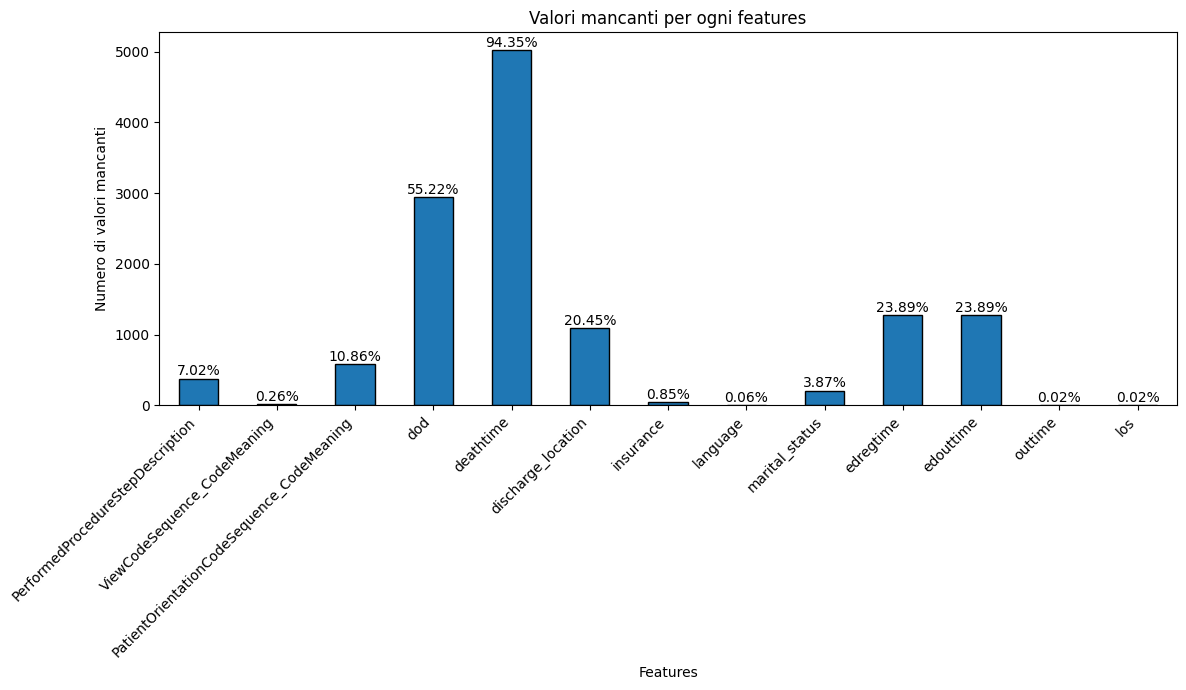

In [42]:
def plot_valori_mancanti(dataset):
    valori_nulli = dataset.isnull().sum()
    valori_nulli = valori_nulli[valori_nulli > 0]
    percentuale = valori_nulli / len(dataset) * 100
    plt.figure(figsize=(12, 7), dpi=100)
    valori_nulli.plot(kind='bar', edgecolor='black')
    for chiave, valore in enumerate(valori_nulli):
        plt.text(chiave, valore + (max(valori_nulli) * 0.01), f"{percentuale.iloc[chiave]:.2f}%", ha='center', fontsize=10)
    plt.title('Valori mancanti per ogni features')
    plt.ylabel('Numero di valori mancanti')
    plt.xlabel('Features')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
        
plot_valori_mancanti(dataset)

Tutti i valori mancanti rappresentano dei dati inutili (eccetto los), perciò procedo con l'eliminazione delle features. Los, invece elimino quei pochissimi record (0,1%), poiché in campo medico è preferibile eliminare le indicisioni (visto la percentuale), piuttosto che generare rumore con l'imputazione.

In [43]:
dataset = dataset.dropna(subset=['los'])

## Gestione dei duplicati

Per prima cosa, si crea una feature unica datetime

In [44]:
dataset['StudyDate_str'] = dataset['StudyDate'].astype(int).astype(str)
dataset['StudyTime_str'] = dataset['StudyTime'].astype(int).astype(str)
dataset['StudyTime_str'] = dataset['StudyTime_str'].str.zfill(6) # HHMMSS
dataset['StudyDateTime'] = pd.to_datetime(
    dataset['StudyDate_str'] + dataset['StudyTime_str'],
    format='%Y%m%d%H%M%S',
    errors='coerce'
)

## Normalizzazione dei dati

Le colonne utili sono subject_id per la primary key, gender, anchor_age, ViewPosition, los, admission_type

In [45]:
colonne_buone = ['subject_id','gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto' , 'stato_clinico', 'numero_severita']
dataset = dataset[colonne_buone].copy()
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto', 'stato_clinico', 'numero_severita']


In [46]:
dataset.head()

,subject_id,gender,anchor_age,ViewPosition,los,admission_type,path_immagine,testo_referto,stato_clinico,numero_severita
0,10001401,F,89,AP,20.528681,EW EMER.,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,TRAUMI,2
1,10324763,M,37,PA,22.175301,EU OBSERVATION,data/MIMIC_SUPER_RES_24K/00155f06-795059b5-c0d...,FINAL REPORT\...,NEGATIVO,0
2,11659116,M,65,PA,12.257338,OBSERVATION ADMIT,data/MIMIC_SUPER_RES_24K/00293039-2e41047e-156...,FINAL REPORT\...,NEGATIVO,0
3,11426592,M,49,AP,0.743900,EW EMER.,data/MIMIC_SUPER_RES_24K/002b60ef-edb03af7-d19...,FINAL REPORT\...,TRAUMI,2
4,10065125,M,74,AP,2.535451,URGENT,data/MIMIC_SUPER_RES_24K/00381899-beea9f9e-375...,FINAL REPORT\...,TRAUMI,2


In [47]:
colonne_feature = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
feature = dataset[colonne_feature].copy()
encoder = LabelEncoder()
feature['gender'] = encoder.fit_transform(feature['gender'])
feature['ViewPosition'] = encoder.fit_transform(feature['ViewPosition'])
feature = pd.get_dummies(feature, columns=['admission_type'], drop_first=True, dtype=float)
feature = feature.astype(float)
feature.head()

,gender,anchor_age,ViewPosition,los,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT
0,0.0,89.0,0.0,20.528681,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,37.0,1.0,22.175301,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,65.0,1.0,12.257338,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,49.0,0.0,0.743900,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,74.0,0.0,2.535451,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Matrice di correlazione e calcolo del VIF

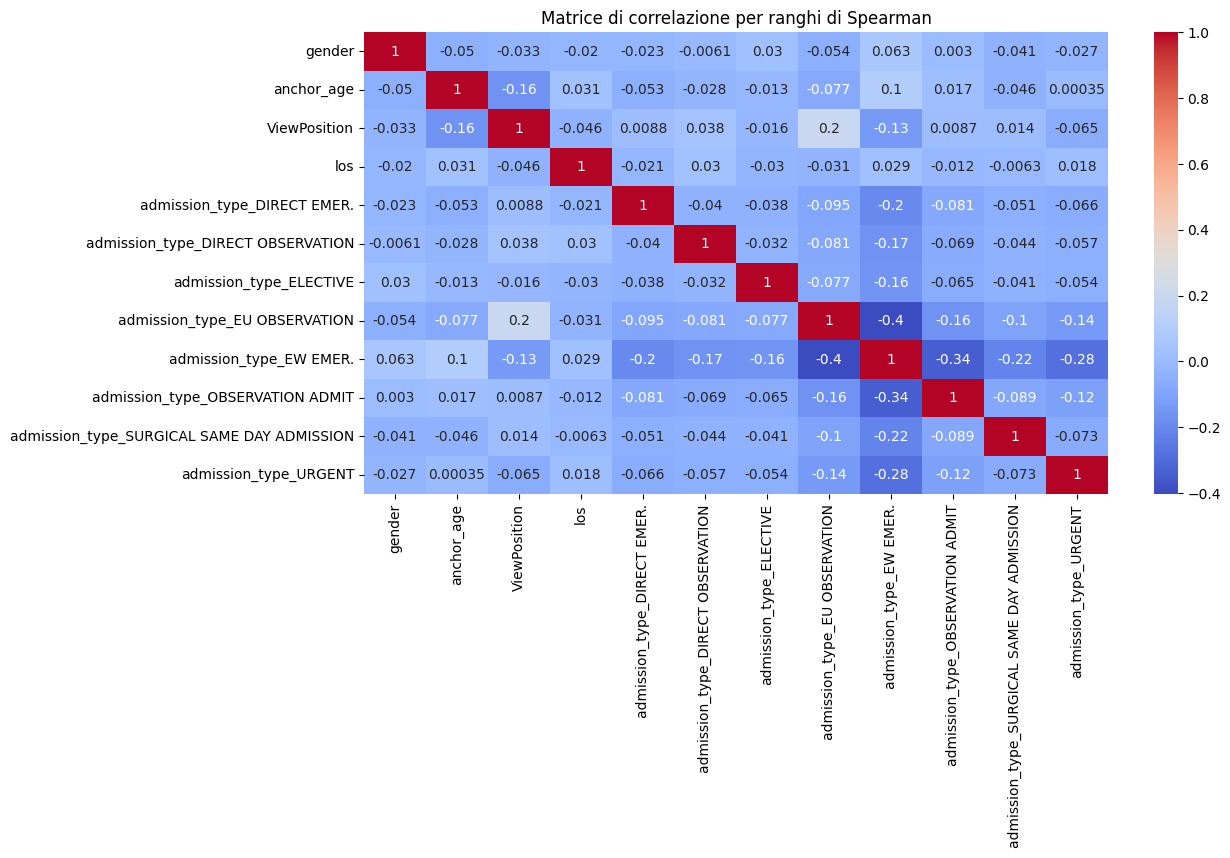

In [48]:
plt.figure(figsize=(12, 6))
plt.title('Matrice di correlazione per ranghi di Spearman')
sns.heatmap(feature.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

In [49]:
vif_data = pd.DataFrame()
vif_data['feature'] = feature.columns
feature_const = sm.add_constant(feature)
vif_data['VIF'] = [variance_inflation_factor(feature_const.values, ind+1) for ind in range(feature.shape[1])]
print(vif_data)

                                       feature        VIF
0                                       gender   1.013877
1                                   anchor_age   1.040756
2                                 ViewPosition   1.075968
3                                          los   1.003805
4                  admission_type_DIRECT EMER.   4.446285
5            admission_type_DIRECT OBSERVATION   3.566033
6                      admission_type_ELECTIVE   3.320764
7                admission_type_EU OBSERVATION  12.040787
8                      admission_type_EW EMER.  20.907876
9             admission_type_OBSERVATION ADMIT   9.738362
10  admission_type_SURGICAL SAME DAY ADMISSION   5.110409
11                       admission_type_URGENT   7.439923


Mapping dei dati

In [50]:
mapping_gender = {'M': 0, 'F': 1}
dataset['gender'] = dataset['gender'].map(mapping_gender)

posizioni_uniche = dataset['ViewPosition'].unique()
mapping_view = {pos: ind for ind, pos in enumerate(posizioni_uniche)}
dataset['ViewPosition'] = dataset['ViewPosition'].map(mapping_view)

ammissioni_uniche = dataset['admission_type'].unique()
mapping_admission = {tipo: ind for ind, tipo in enumerate(ammissioni_uniche)}
dataset['admission_type'] = dataset['admission_type'].map(mapping_admission)

dataset['anchor_age'] = pd.to_numeric(dataset['anchor_age'], errors='coerce').fillna(0).astype(int)
dataset['los'] = pd.to_numeric(dataset['los'], errors='coerce').fillna(0).astype(float)

colonne_mappate = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
print("Dtypes dopo la conversione:")
print(dataset[colonne_mappate].dtypes)

# Mostriamo i mapping (salvali per la tesi!)
print("\nMapping ViewPosition:", mapping_view)
print("Mapping AdmissionType:", mapping_admission)

Dtypes dopo la conversione:
gender              int64
anchor_age          int64
ViewPosition        int64
los               float64
admission_type      int64
dtype: object

Mapping ViewPosition: {'AP': 0, 'PA': 1}
Mapping AdmissionType: {'EW EMER.': 0, 'EU OBSERVATION': 1, 'OBSERVATION ADMIT': 2, 'URGENT': 3, 'SURGICAL SAME DAY ADMISSION': 4, 'DIRECT OBSERVATION': 5, 'ELECTIVE': 6, 'DIRECT EMER.': 7, 'AMBULATORY OBSERVATION': 8}


Come si può notare, ogni feature possiede colinearità debole, perciò è del tutto inutile eseguire procedure di riduzione di dimensionalità. Ovviamente, le colonne esplose hanno VIF altissimo, ma è del tutto normale

# Parte 3: Distribuzione dei dati

L'unico dato rilevante per calcolare gli outliers è l'anchor_age, poiché è l'unica variabile continua e può mostrare la demografia dei pazienti. I box-plot sugli altri dati non fornirebbe dati interessanti per il modello. Perciò, il box-plot viene fatto su anchor_age diviso per stadio_clinico, per vedere le fascie di età più colpite.

In [51]:
print(dataset.columns.tolist())

['subject_id', 'gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type', 'path_immagine', 'testo_referto', 'stato_clinico', 'numero_severita']


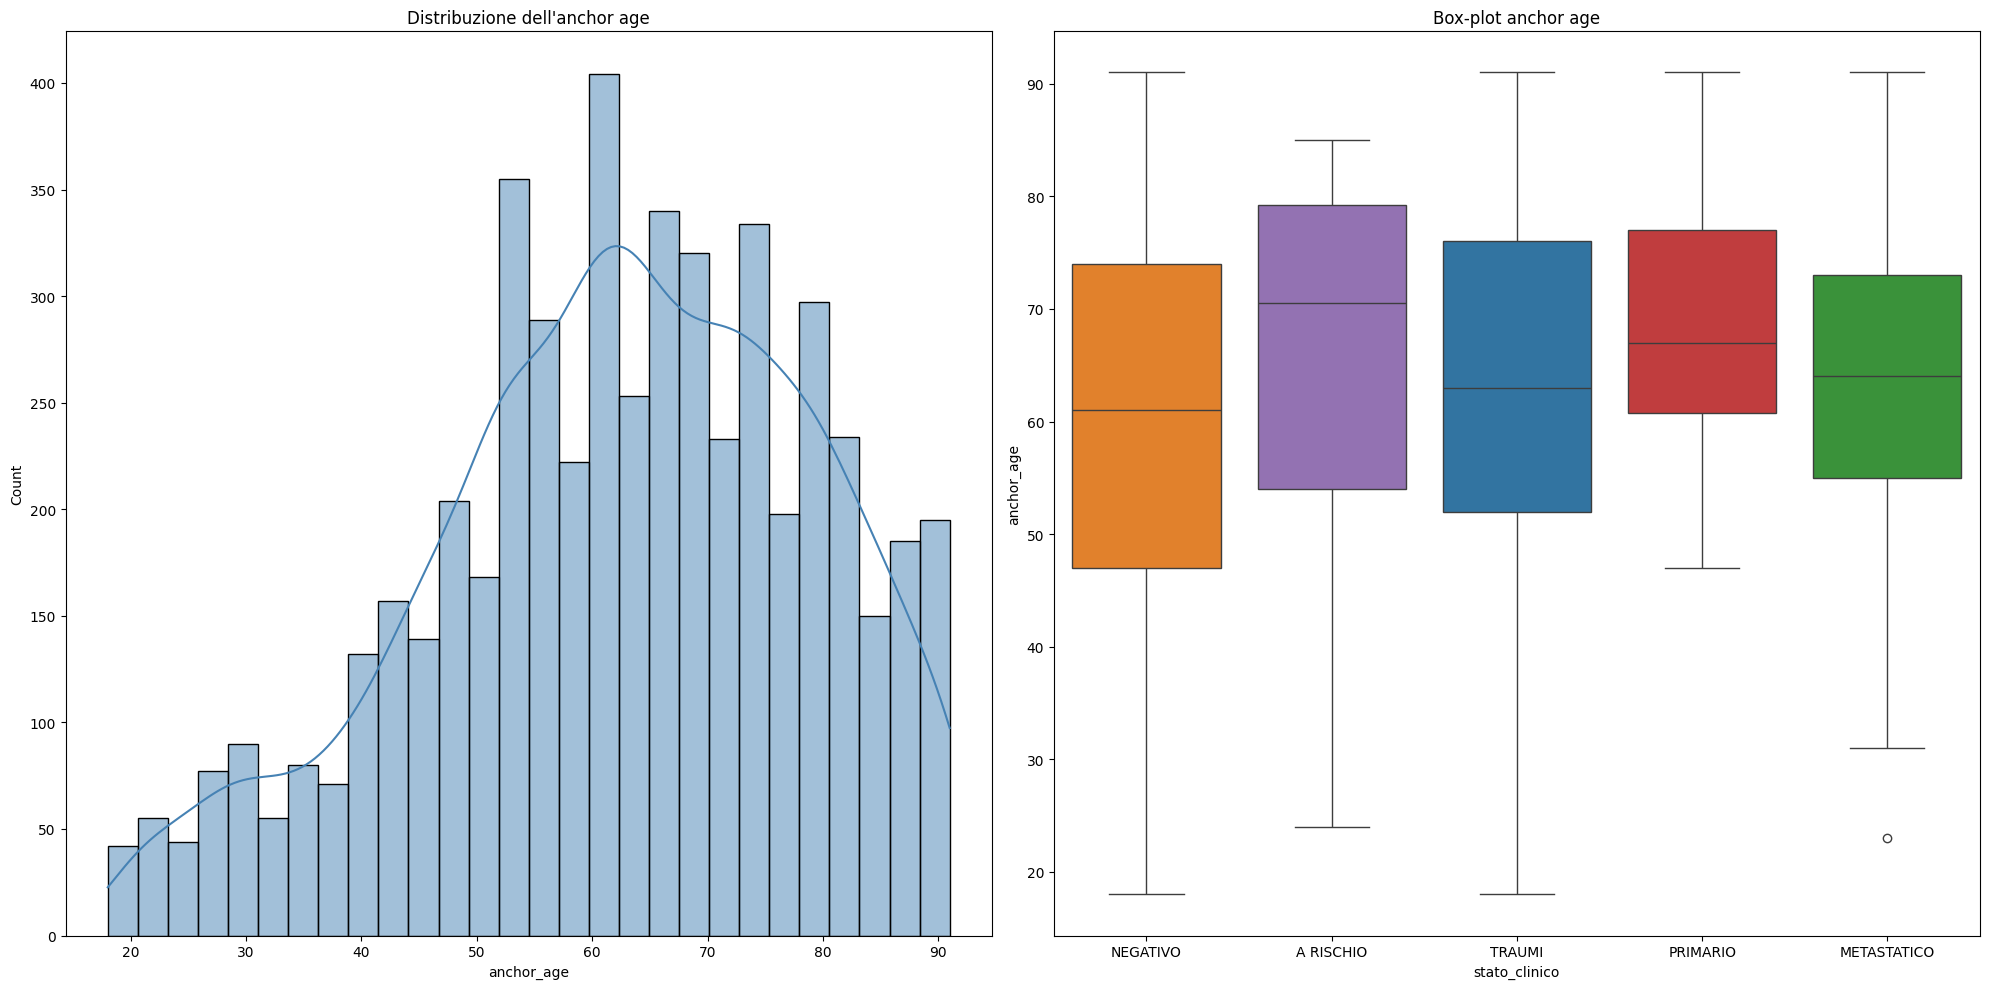

In [52]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
ordine_clinico = [
    'NEGATIVO', 
    'A RISCHIO',
    'TRAUMI',
    'PRIMARIO', 
    'METASTATICO'
]
sns.histplot(dataset['anchor_age'], kde=True, ax=axis[0], color='steelblue')
sns.boxplot(x='stato_clinico', y='anchor_age', data=dataset, order=ordine_clinico ,ax=axis[1], hue='stato_clinico', legend=False)
axis[0].set_title("Distribuzione dell'anchor age")
axis[1].set_title("Box-plot anchor age")
plt.tight_layout()
plt.show()

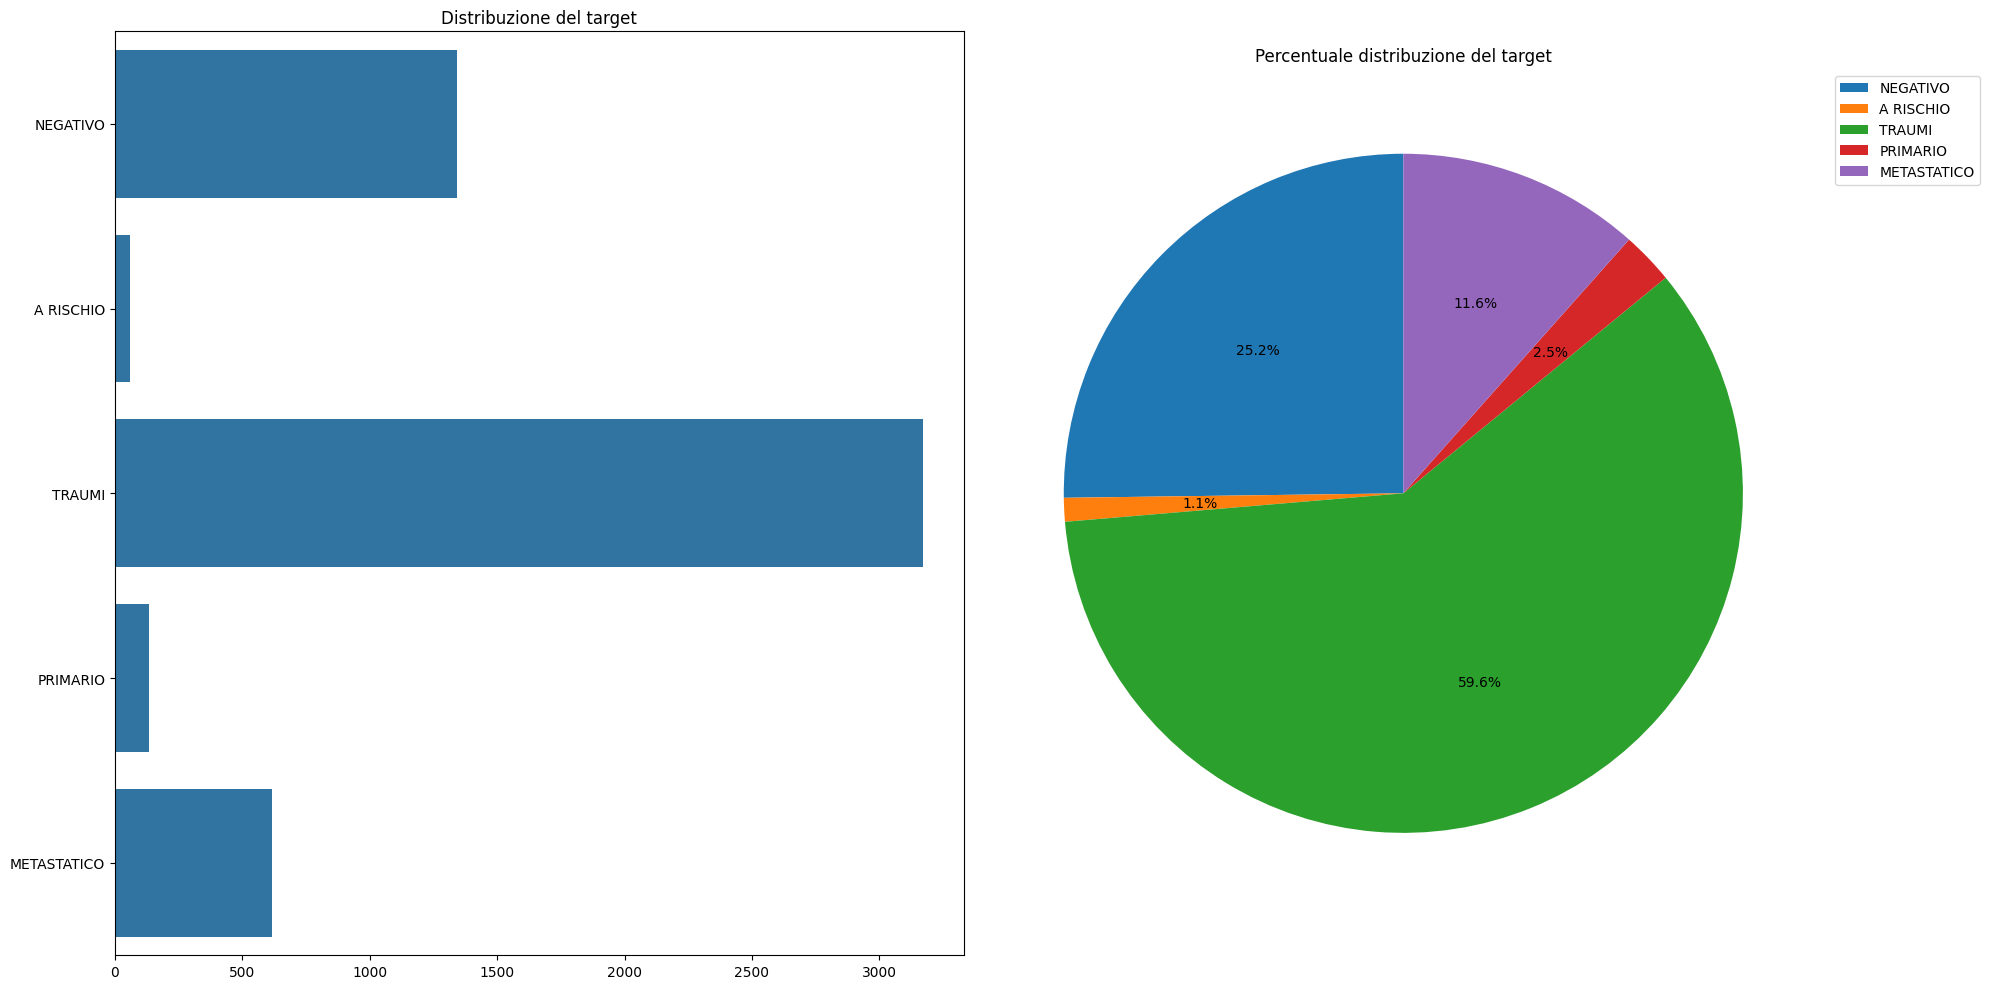

In [53]:
fig, axis = plt.subplots(1, 2, figsize=(20, 10))
target_counts = dataset['stato_clinico'].value_counts().reindex(ordine_clinico).fillna(0)
sns.barplot(x=target_counts.values, y=ordine_clinico, ax=axis[0])
axis[1].pie(target_counts.values, labels=None, autopct='%1.1f%%', startangle=90)
axis[0].set_title("Distribuzione del target")
axis[1].set_title("Percentuale distribuzione del target")
axis[1].legend(labels=ordine_clinico, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Come si può notare, il dataset è molto sbilanciato di casi negativi. Per il momento, escludiamo i negativi.

Come si può notare, il dataset dei positivi risulta leggermente più bilanciato. Perciò, si procede con il data augumentation del I-III stadio, poiché i casi sono veramente rari; e con l'Weighted Cross-Entropy Loss, perché non è presente molta differenza con quelli a rischio. 

In [54]:
dataset_pazienti = dataset[['subject_id', 'numero_severita']].drop_duplicates(subset=['subject_id'])
train_pazienti, temp_pazienti = train_test_split(
    dataset_pazienti,
    test_size = 0.20,
    stratify = dataset_pazienti['numero_severita'],
    random_state = 42
)
val_pazienti, test_pazienti = train_test_split(
    temp_pazienti,
    test_size = 0.50,
    stratify = temp_pazienti['numero_severita'],
    random_state = 42
)
train_set = dataset[dataset['subject_id'].isin(train_pazienti['subject_id'])].copy()
validation_set = dataset[dataset['subject_id'].isin(val_pazienti['subject_id'])].copy()
test_set = dataset[dataset['subject_id'].isin(test_pazienti['subject_id'])].copy()
train_set

,subject_id,gender,anchor_age,ViewPosition,los,admission_type,path_immagine,testo_referto,stato_clinico,numero_severita
0,10001401,1,89,0,20.528681,0,data/MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824...,FINAL REPORT\...,TRAUMI,2
1,10324763,0,37,1,22.175301,1,data/MIMIC_SUPER_RES_24K/00155f06-795059b5-c0d...,FINAL REPORT\...,NEGATIVO,0
3,11426592,0,49,0,0.743900,0,data/MIMIC_SUPER_RES_24K/002b60ef-edb03af7-d19...,FINAL REPORT\...,TRAUMI,2
4,10065125,0,74,0,2.535451,3,data/MIMIC_SUPER_RES_24K/00381899-beea9f9e-375...,FINAL REPORT\...,TRAUMI,2
6,11674366,0,70,0,0.638125,0,data/MIMIC_SUPER_RES_24K/003b790a-1e923d5f-da1...,FINAL REPORT\...,NEGATIVO,0
...,...,...,...,...,...,...,...,...,...,...
5315,10528671,0,62,0,1.789560,0,data/MIMIC_SUPER_RES_24K/ff8cc3fb-75f7f2bf-ee1...,FINAL REPORT\...,NEGATIVO,0
5316,11492213,0,54,0,5.369514,0,data/MIMIC_SUPER_RES_24K/ff8d2cb5-efbaeeca-f7f...,FINAL REPORT\...,TRAUMI,2
5319,10620832,0,41,0,2.141713,0,data/MIMIC_SUPER_RES_24K/ffc7c57a-cb1f20c6-d2d...,FINAL REPORT\...,NEGATIVO,0
5321,11931339,1,91,0,2.311377,1,data/MIMIC_SUPER_RES_24K/ffd2d0da-b7ec6554-561...,FINAL REPORT\...,TRAUMI,2


In [55]:
print("--- DISTRIBUZIONE TRAIN SET ---")
print(train_set['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE TRAIN SET ---
stato_clinico
TRAUMI         2529
NEGATIVO       1076
METASTATICO     490
PRIMARIO        101
A RISCHIO        47
Name: count, dtype: int64

Totale immagini per l'addestramento: 4243


## Data augmentation

In [56]:
base = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BILINEAR), 
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

augmentation = T.Compose([
    T.RandomResizedCrop(224, scale=(0.9, 1.0)), # Simula zoom/distanze diverse
    T.RandomRotation(degrees=7), # Aumentato leggermente a 7 gradi
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Traslazioni leggermente più marcate
    T.ColorJitter(brightness=0.2, contrast=0.2), # Fondamentale per RX: simula diverse esposizioni
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

## Undersampling

Per eseguire l'undersampling, trovo i pazienti sani simili, con la logica degli N-grammi e la Cosine Similarity.

In [57]:
model_st = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
df_traumi = train_set[train_set['stato_clinico'] == 'TRAUMI'].copy()
sentences = df_traumi['testo_referto'].tolist()
embeddings = model_st.encode(sentences, convert_to_tensor=True)
centroid = torch.mean(embeddings, dim=0)
cosine_scores = util.cos_sim(embeddings, centroid).flatten()
top_k_indices = torch.topk(cosine_scores, k=1068).indices.cpu().numpy()
df_traumi_top = df_traumi.iloc[top_k_indices]
altre_classi = train_set[train_set['numero_severita'] != 2]
train_set_sbilanciato = pd.concat([df_traumi_top, altre_classi]).sample(frac=1).reset_index(drop=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [58]:
def bilancia_dataframe_a_1000(df, df_traumi_top):
    target_n = 1068
    nuovi_pezzi = []
    
    for classe in [0, 1, 2, 3, 4]:
        if classe == 2:
            if df_traumi_top is not None and not df_traumi_top.empty:
                nuovi_pezzi.append(df_traumi_top)
        else:
            df_classe = df[df['numero_severita'] == classe]
            
            if not df_classe.empty:
                # Calcoliamo quante volte replicare la classe per arrivare a 1000
                moltiplicatore = (target_n // len(df_classe)) + 1
                df_aug = pd.concat([df_classe] * moltiplicatore, ignore_index=True)
                
                # Tagliamo esattamente a 1000 e aggiungiamo alla lista
                nuovi_pezzi.append(df_aug.iloc[:target_n])
            else:
                print(f"Attenzione: La classe {classe} è vuota nel dataframe di input!")
            
    # Ora la lista nuovi_pezzi contiene 5 dataframe da 1000 righe ciascuno
    return pd.concat(nuovi_pezzi).sample(frac=1).reset_index(drop=True)

# Ora lancia il comando
train_set_bilanciato = bilancia_dataframe_a_1000(train_set, df_traumi_top)

In [59]:
print("--- DISTRIBUZIONE FINALE TRAIN SET ---")
print(train_set_bilanciato['stato_clinico'].value_counts())
print(f"\nTotale immagini per l'addestramento: {len(train_set)}")

--- DISTRIBUZIONE FINALE TRAIN SET ---
stato_clinico
NEGATIVO       1068
TRAUMI         1068
PRIMARIO       1068
A RISCHIO      1068
METASTATICO    1068
Name: count, dtype: int64

Totale immagini per l'addestramento: 4243


## Weighted Cross-Entropy

In [60]:
def calcola_pesi_loss(dataframe, augmentation=True):
    conta = dataframe['numero_severita'].value_counts()
    
    # Conteggi (assumendo Negativo e Traumi a 1000, gli altri originali)
    n0 = 1068  # NEGATIVO
    n1 = conta.get(1, 1) # A RISCHIO (33)
    n2 = 1068 # TRAUMI
    n3 = conta.get(3, 1) # PRIMARIO (88)
    n4 = conta.get(4, 1) # METASTATICO (414)

    if not augmentation:
        # Senza augmentation: pesi alti per compensare lo sbilanciamento
        pesi = [1.0, n0/n1, 1.0, n0/n3, n0/n4]
    else:
        # Con augmentation e oversampling: tutte le classi pesano uguale
        pesi = [1.0, 1.0, 1.0, 1.0, 1.0]
        
    return torch.tensor(pesi, dtype=torch.float32)

Con Augmentation

In [61]:
pesi_aug = calcola_pesi_loss(train_set, augmentation=True)
pesi_baseline = calcola_pesi_loss(train_set, augmentation=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parte 4: Addestramento e risultati

In [62]:
ricerca_train = os.path.join(os.getcwd())

In [63]:
# Training clinico
feat_cols = ['gender', 'anchor_age', 'ViewPosition', 'los', 'admission_type']
clinical_model = train_modello_clinico(train_set_bilanciato, validation_set, feat_cols)


--- TRAINING MODELLO CLINICO ---
[0]	validation_0-mlogloss:1.60710


[100]	validation_0-mlogloss:1.50033
[200]	validation_0-mlogloss:1.45119
[300]	validation_0-mlogloss:1.42414
[400]	validation_0-mlogloss:1.41334
[499]	validation_0-mlogloss:1.41079


In [64]:
from PIL import Image

# Disabilita il limite di sicurezza per le immagini mediche ad altissima risoluzione
Image.MAX_IMAGE_PIXELS = None

In [ ]:
# Training modello visivo con augmentation
modello_aug, hist_aug = train_modello_visivo(
    train_set_bilanciato, 
    validation_set, 
    ricerca_train, 
    base, 
    augmentation, 
    pesi=pesi_aug,
    device=device, 
    use_aug=True
)

In [ ]:
# Training modello visivo senza augmentation
modello_baseline, hist_baseline = train_modello_visivo(
    train_set_sbilanciato, 
    validation_set, 
    ricerca_train, 
    base, 
    augmentation, 
    pesi=pesi_baseline,
    device=device, 
    use_aug=False
)

In [ ]:
dataset_test = RXToraceDataset(
    dataframe=test_set, 
    cartella=ricerca_train, 
    transform_base=base, 
    transform_aug=None, 
    is_train=False
)
test_loader = DataLoader(
    dataset_test, 
    batch_size=32,   
    shuffle=False,   
)
evaluator = Evaluator(['NEGATIVO', 'A RISCHIO', 'TRAUMI', 'PRIMARIO', 'METASTATICO'])


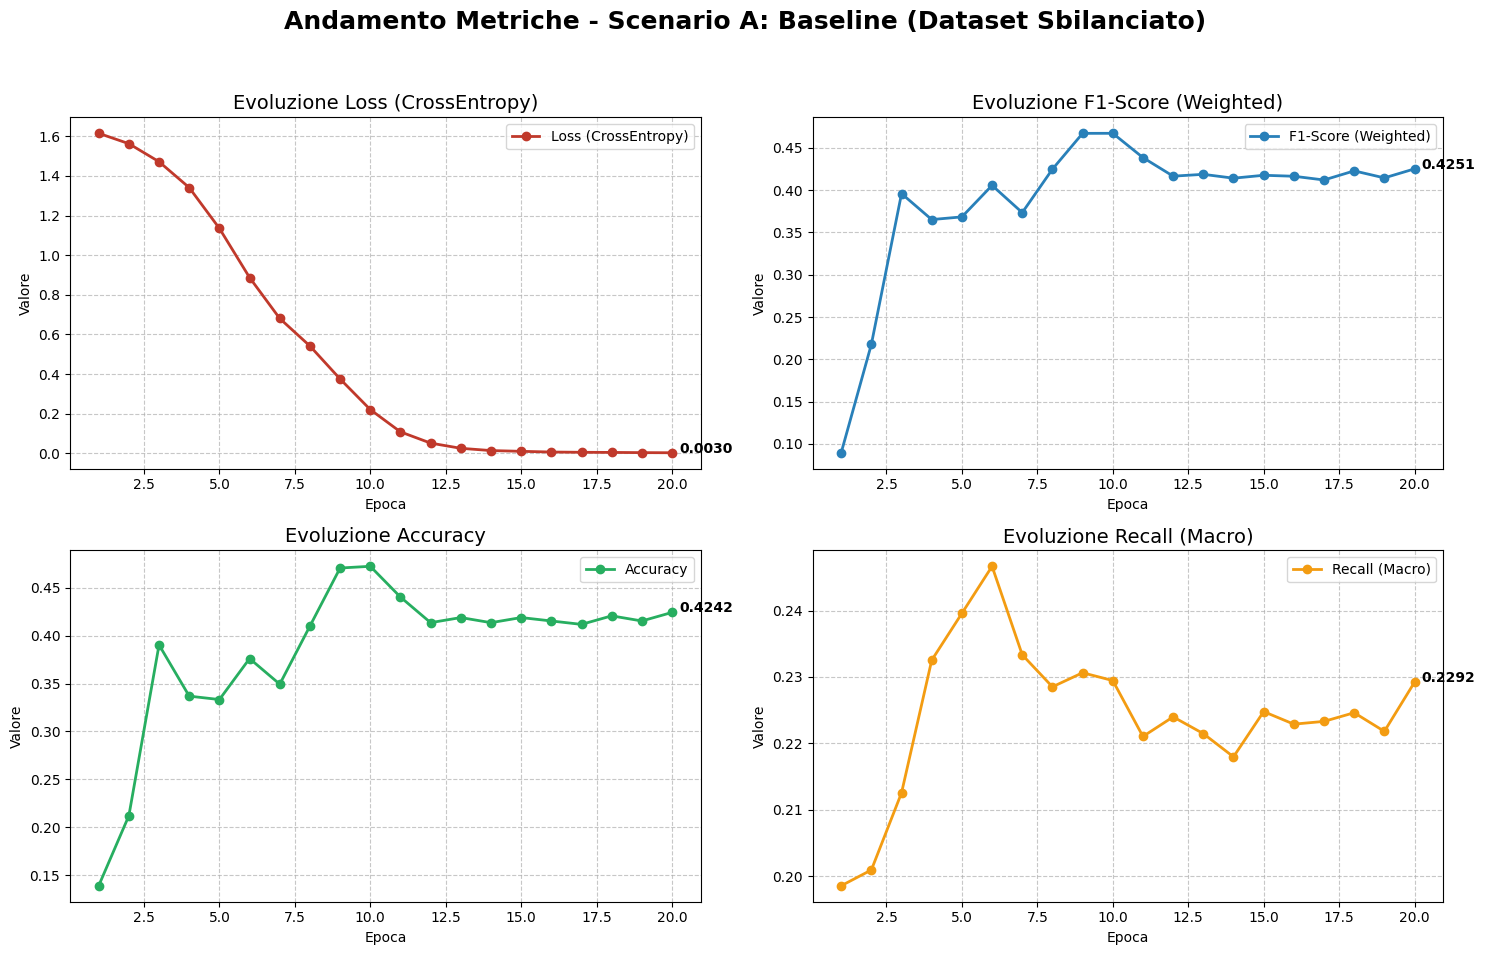

In [ ]:
evaluator.plot_training_history(
    history=hist_baseline, 
    titolo="Scenario A: Baseline (Dataset Sbilanciato)", 
    nome_file="baseline"
)

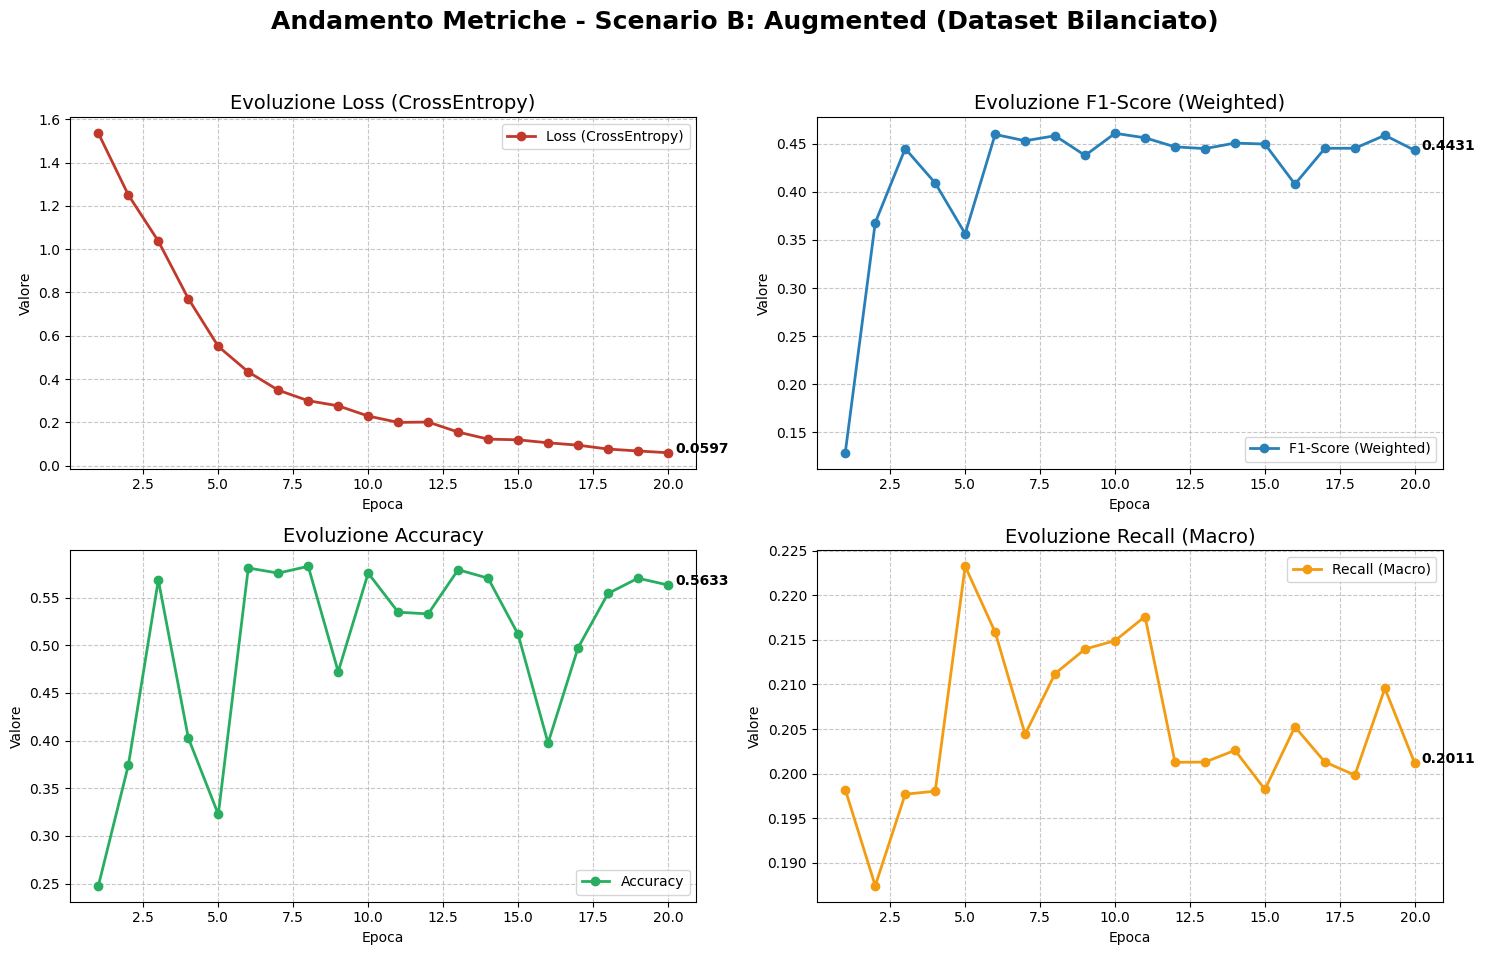

In [ ]:
evaluator.plot_training_history(
    history=hist_aug, 
    titolo="Scenario B: Augmented (Dataset Bilanciato)", 
    nome_file="augmented"
)

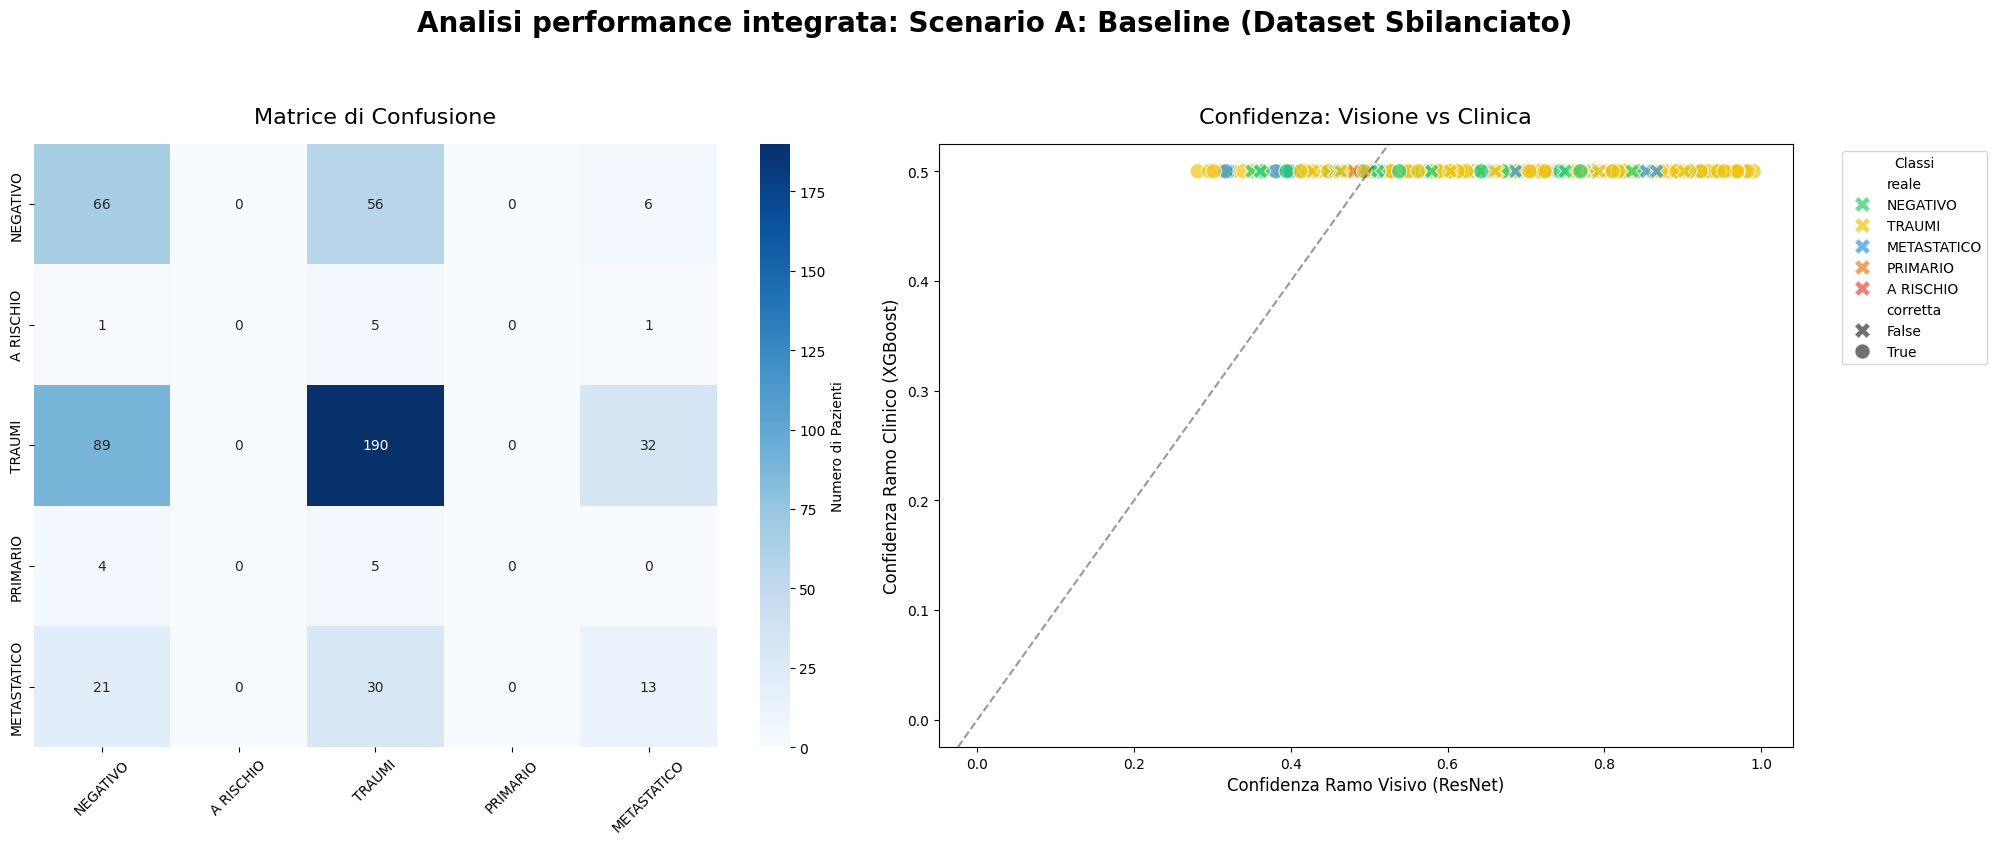

In [117]:
risultati_df = evaluator.evaluate_model(modello_baseline, test_loader)
evaluator.plot_scenario_performance(
    res_df=risultati_df, 
    titolo="Scenario A: Baseline (Dataset Sbilanciato)", 
    nome_file="baseline_gr"
)

Avvio valutazione su cpu...


  0%|          | 0/17 [00:00<?, ?it/s]

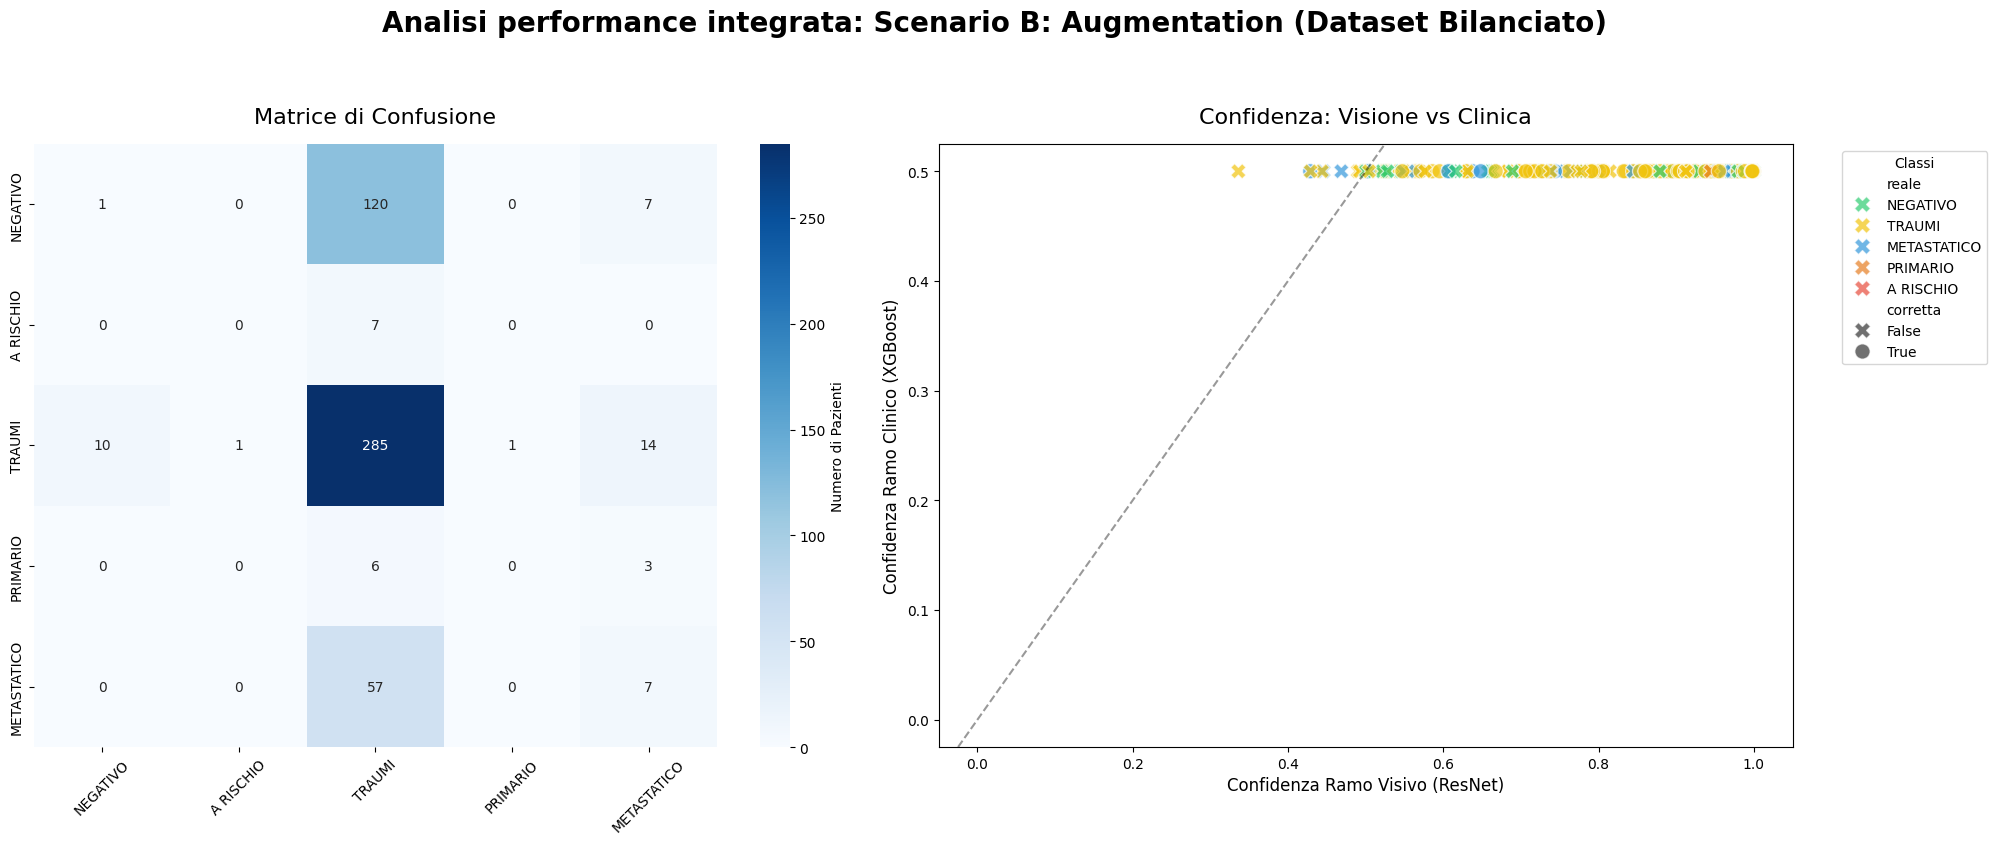

In [118]:
risultati_df1 = evaluator.evaluate_model(modello_aug, test_loader)
evaluator.plot_scenario_performance(
    res_df=risultati_df1, 
    titolo="Scenario B: Augmentation (Dataset Bilanciato)", 
    nome_file="aug_gr"
)

# Conclusioni

Paradossalmente, il sistema risulta più preciso senza augmentation, poiché il sistema rileva le immagini troppo simili e capisce che risulta più semplice classificare dei traumi (overfitting). Il vero problema è la recall, poiché si avvicina molto alla soglia $\frac{1}{5}$, che appunto come tirare ad indovinare. Per questo motivo, risulta necessario affidarci al anche alla Diagnosi clinica, assegnando i giusti pesi.